Configuración y Limpieza

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns
# 1. Carga de datos
df_calendar = pd.read_csv('../data/calendar_limpio.csv.zip', compression='zip', parse_dates=['date'])
df_listings = pd.read_csv('../data/listings_limpio.csv')

# Merge: Solo necesitamos el barrio y el tipo de cuarto para luego (ignoramos el precio aquí)
airbnb = pd.merge(df_calendar, df_listings[['id', 'neighbourhood_cleansed', 'room_type']], 
            left_on='listing_id', right_on='id', how='left')

# 2. LA MAGIA DE LA OCUPACIÓN
# 'available' suele venir como 't' (True, libre) o 'f' (False, ocupado). 
# Lo convertimos a 1 (Ocupado) y 0 (Libre) para poder hacer la media.
airbnb['ocupado'] = airbnb['available'].map({'f': 1, 't': 0, False: 1, True: 0})


# 3. Ingeniería de Fechas Extendida
def etiquetar_evento(fecha):
    f_str = str(fecha.date())
    if ('2024-04-14' <= f_str <= '2024-04-20') or ('2025-05-06' <= f_str <= '2025-05-11'): return 'Feria de Abril'
    elif ('2024-03-24' <= f_str <= '2024-03-31') or ('2025-04-13' <= f_str <= '2025-04-20'): return 'Semana Santa'
    elif ('2023-12-22' <= f_str <= '2024-01-06') or ('2024-12-22' <= f_str <= '2025-01-06'): return 'Navidad'
    elif ('2023-12-05' <= f_str <= '2023-12-10') or ('2024-12-05' <= f_str <= '2024-12-09'): return 'Puente Diciembre'
    elif ('2023-10-11' <= f_str <= '2023-10-15') or ('2024-10-11' <= f_str <= '2024-10-13'): return 'Puente Hispanidad'
    else: return 'Normal'

airbnb['evento'] = airbnb['date'].apply(etiquetar_evento)
airbnb['es_finde'] = airbnb['date'].dt.dayofweek.isin([4, 5, 6]) # Viernes, Sábado, Domingo

# 4. Afinar el periodo: Separar "Normal" en findes y entre semana
def afinar_periodo(row):
    if row['evento'] != 'Normal':
        return row['evento']
    else:
        return 'Finde Normal' if row['es_finde'] else 'Semana Normal'

airbnb['periodo'] = airbnb.apply(afinar_periodo, axis=1)

print(f"✅ Datos listos. Total de días procesados: {len(airbnb)}")

✅ Datos listos. Total de días procesados: 2998475


Inflación de los precios por las fiestas

In [11]:
# =====================================================================
# 2. ETIQUETADO DE EVENTOS AVANZADO (Actualizado a 2025/2026)
# =====================================================================
# Por defecto, todo es Normal
airbnb['evento'] = 'Normal'

# NAVIDAD (Del 22 dic al 6 ene - Da igual el año)
mask_navidad = ((airbnb['date'].dt.month == 12) & (airbnb['date'].dt.day >= 22)) | \
               ((airbnb['date'].dt.month == 1) & (airbnb['date'].dt.day <= 6))
airbnb.loc[mask_navidad, 'evento'] = 'Navidad'

# PUENTE DICIEMBRE (Del 5 al 10 dic)
mask_pdic = (airbnb['date'].dt.month == 12) & (airbnb['date'].dt.day.between(5, 10))
airbnb.loc[mask_pdic, 'evento'] = 'Puente Diciembre'

# PUENTE HISPANIDAD (Del 11 al 15 oct)
mask_hisp = (airbnb['date'].dt.month == 10) & (airbnb['date'].dt.day.between(11, 15))
airbnb.loc[mask_hisp, 'evento'] = 'Puente Hispanidad'

# PUENTE DE MAYO (1 al 3 de mayo)
mask_mayo = (airbnb['date'].dt.month == 5) & (airbnb['date'].dt.day.between(1, 3))
airbnb.loc[mask_mayo, 'evento'] = 'Puente de Mayo'

# FERIA DE ABRIL (Fechas exactas de 2025 y 2026)
mask_feria = ((airbnb['date'] >= '2025-05-05') & (airbnb['date'] <= '2025-05-11')) | \
             ((airbnb['date'] >= '2026-04-20') & (airbnb['date'] <= '2026-04-26'))
airbnb.loc[mask_feria, 'evento'] = 'Feria de Abril'

# SEMANA SANTA (Fechas exactas de 2025 y 2026)
mask_ss = ((airbnb['date'] >= '2025-04-13') & (airbnb['date'] <= '2025-04-20')) | \
          ((airbnb['date'] >= '2026-03-29') & (airbnb['date'] <= '2026-04-05'))
airbnb.loc[mask_ss, 'evento'] = 'Semana Santa'

# =====================================================================
# 3. SEPARAR FINDE VS SEMANA (Optimizado con Numpy)
# =====================================================================
airbnb['es_finde'] = airbnb['date'].dt.dayofweek.isin([4, 5, 6])

airbnb['periodo'] = np.where(
    airbnb['evento'] != 'Normal', 
    airbnb['evento'], 
    np.where(airbnb['es_finde'], 'Finde Normal', 'Semana Normal')
)

C:\Users\delga\AppData\Local\Temp\ipykernel_8132\4255865300.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(x=resumen_ocupacion.index, y=resumen_ocupacion.values, palette="mako")


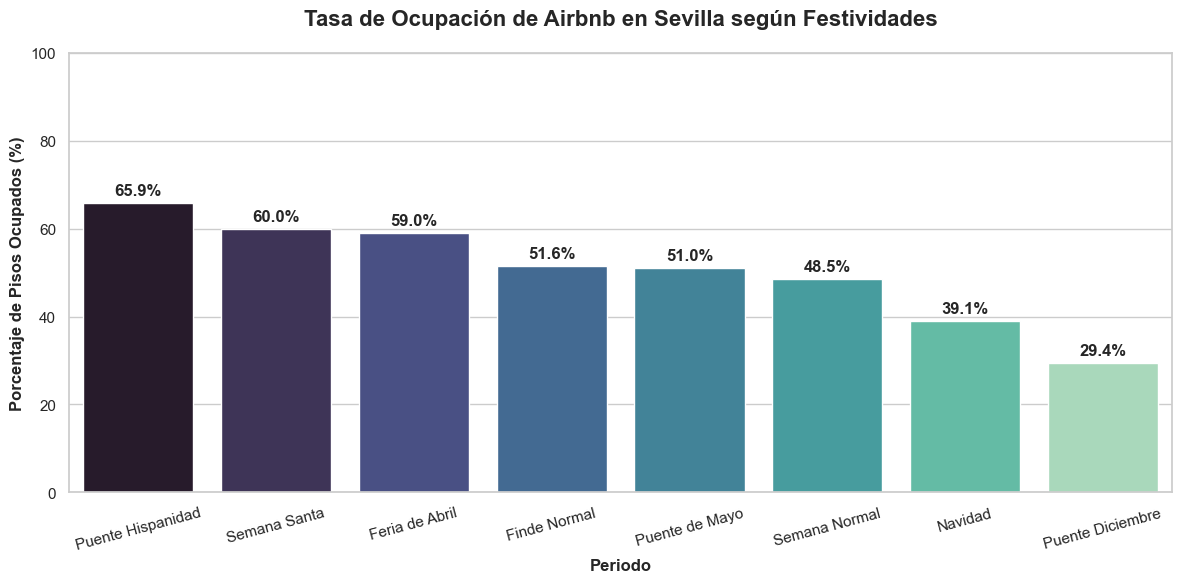

In [14]:
# =====================================================================
# 4. GRÁFICO DE OCUPACIÓN
# =====================================================================
# Calculamos ocupación media
resumen_ocupacion = (airbnb.groupby('periodo')['ocupado'].mean() * 100).sort_values(ascending=False)

# Pintamos
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

grafico = sns.barplot(x=resumen_ocupacion.index, y=resumen_ocupacion.values, palette="mako")

for p in grafico.patches:
    grafico.annotate(f"{p.get_height():.1f}%", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 9), 
                     textcoords = 'offset points',
                     fontweight='bold')

plt.title('Tasa de Ocupación de Airbnb en Sevilla según Festividades', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Porcentaje de Pisos Ocupados (%)', fontweight='bold')
plt.xlabel('Periodo', fontweight='bold')

plt.ylim(0, 100) 
plt.xticks(rotation=15) 
plt.tight_layout()
plt.show()

🔥 Generando Heatmap de Ocupación Mensual...


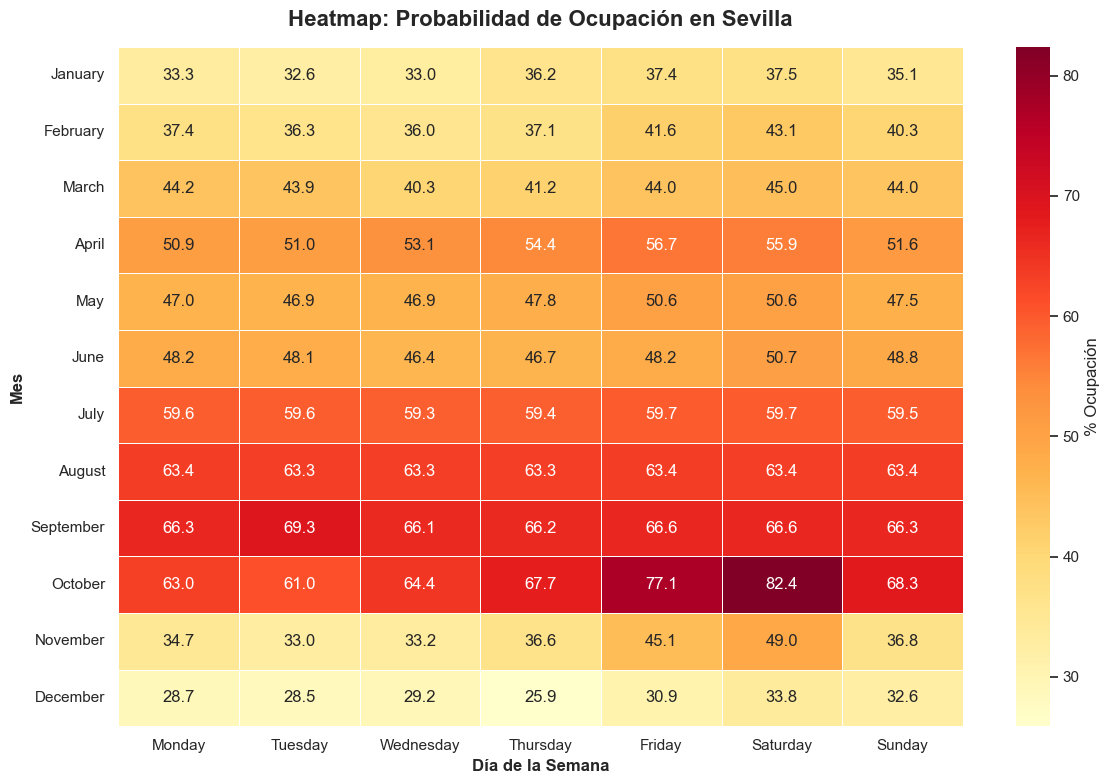

In [7]:
# =====================================================================
# MAPA DE CALOR: PROBABILIDAD DE OCUPACIÓN (MES VS DÍA)
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("🔥 Generando Heatmap de Ocupación Mensual...")

# 1. Aseguramos tener los nombres de mes y día (si no los tenías creados)
airbnb['mes_nombre'] = airbnb['date'].dt.month_name()
airbnb['dia_semana_nombre'] = airbnb['date'].dt.day_name()

# 2. Creamos la tabla pivote (multiplicada por 100 para ver porcentajes)
pivot_ocupacion = airbnb.pivot_table(
    index='mes_nombre', 
    columns='dia_semana_nombre', 
    values='ocupado', 
    aggfunc='mean'
) * 100

# 3. Ordenamos los días y los meses de forma lógica (cronológica)
dias_ordenados = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
meses_ordenados = ['January', 'February', 'March', 'April', 'May', 'June', 
                   'July', 'August', 'September', 'October', 'November', 'December']

# Reindexamos la tabla para aplicar el orden
pivot_ocupacion = pivot_ocupacion.reindex(index=meses_ordenados, columns=dias_ordenados)

# 4. Dibujamos el Mapa de Calor
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_ocupacion, annot=True, cmap='YlOrRd', fmt=".1f", linewidths=.5, cbar_kws={'label': '% Ocupación'})

plt.title('Heatmap: Probabilidad de Ocupación en Sevilla', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Mes', fontweight='bold')
plt.xlabel('Día de la Semana', fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
# =====================================================================
# DEMOSTRACIÓN BIG DATA CON DASK (Procesamiento Paralelo)
# =====================================================================
import dask.dataframe as dd
import time

print("🚀 Iniciando procesamiento Big Data con Dask...")
inicio = time.time()

# 1. Lectura Perezosa (Lazy Loading)
# Al usar Dask, el archivo no se carga en RAM de golpe. 
# Nota: blocksize=None es necesario cuando leemos archivos ZIP directamente en Dask.
ddf_calendar = dd.read_csv('../data/calendar_limpio.csv.zip', compression='zip', blocksize=None)

# 2. Transformación de datos distribuida
# Mapeamos la disponibilidad igual que en Pandas, pero Dask solo crea el "plan de ejecución"
ddf_calendar['ocupado'] = ddf_calendar['available'].map({'f': 1, 't': 0, False: 1, True: 0}, meta=('available', 'int8'))

# 3. Operación de Agrupación (Reduce)
# Queremos saber la ocupación media global por fecha (procesando millones de filas)
ocupacion_por_dia_dask = ddf_calendar.groupby('date')['ocupado'].mean()

print("⏳ Plan de ejecución creado. Dask está listo para computar en paralelo...")

# 4. EL MOMENTO BIG DATA: .compute()
# Aquí es donde Dask coge todos los núcleos de tu procesador y ejecuta el cálculo
ocupacion_por_dia_pandas = ocupacion_por_dia_dask.compute()

fin = time.time()

print(f"✅ ¡Cálculo completado en {fin - inicio:.2f} segundos!")
print("-" * 40)
print("Top 5 Días con mayor ocupación en todo el año (Cálculo Distribuido):")
# Pasamos la fecha a formato datetime para que quede bonito y mostramos el top 5
ocupacion_por_dia_pandas.index = pd.to_datetime(ocupacion_por_dia_pandas.index)
print((ocupacion_por_dia_pandas * 100).sort_values(ascending=False).head(5))

🚀 Iniciando procesamiento Big Data con Dask...
⏳ Plan de ejecución creado. Dask está listo para computar en paralelo...
✅ ¡Cálculo completado en 3.72 segundos!
----------------------------------------
Top 5 Días con mayor ocupación en todo el año (Cálculo Distribuido):
date
2025-09-29    100.000000
2025-10-04     91.710286
2025-10-03     90.979915
2025-10-11     84.856969
2025-10-10     84.796105
Name: ocupado, dtype: float64
